In [1]:
import os

# Set your Kaggle API Token from the screenshot
os.environ['KAGGLE_API_TOKEN'] = "KGAT_4344e5c3203d76bd8f2962bcd2c4072a"

# 1. Download the "Surface Crack Detection" dataset
!kaggle datasets download -d arunrk7/surface-crack-detection

# 2. Unzip the data into a folder called 'material_dataset'
!unzip -q surface-crack-detection.zip -d material_dataset/

print("Success! Your material images are ready.")

Dataset URL: https://www.kaggle.com/datasets/arunrk7/surface-crack-detection
License(s): copyright-authors
100% 233M/233M [00:01<00:00, 132MB/s]

Success! Your material images are ready.


In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. This is your "Optimised Data Preprocessing Pipeline"
transform = transforms.Compose([
    transforms.Resize((128, 128)),   # Resizing makes the data smaller and faster to process
    transforms.Grayscale(num_output_channels=1), # Grayscale (1 channel) is much lighter than RGB (3 channels)
    transforms.ToTensor(),           # Converts the images into a mathematical format for PyTorch
    transforms.Normalize((0.5,), (0.5,)) # Standardizes the data
])

# 2. Load the data from the folder we just downloaded
dataset = datasets.ImageFolder('material_dataset/', transform=transform)

# 3. Split the 40,000 images: 32,000 for the AI to learn from, 8,000 to test its accuracy
train_set, test_set = torch.utils.data.random_split(dataset, [32000, 8000])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

print(f"Boom! Data is preprocessed. We have {len(train_set)} training samples and {len(test_set)} testing samples ready to go.")

Boom! Data is preprocessed. We have 32000 training samples and 8000 testing samples ready to go.


In [3]:
import torch.nn as nn
import torch.optim as optim

# 1. Define the CNN Architecture (The "Brain")
class DefectDetectorCNN(nn.Module):
    def __init__(self):
        super(DefectDetectorCNN, self).__init__()
        # First magnifying glass: looks for basic edges
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second magnifying glass: looks for complex crack patterns
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Final decision maker (Crack vs. No Crack)
        self.fc1 = nn.Linear(32 * 32 * 32, 2)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1) # Flatten the image data
        x = self.fc1(x)
        return x

# 2. Set up the model, the scorer (loss), and the optimizer (Adam)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DefectDetectorCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Train the Model for 2 rounds (epochs) just to see how fast it learns
epochs = 2
print("Starting Training... grab a coffee, this will take a few minutes!")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Round {epoch+1} complete! Data processed.")

# 4

Starting Training... grab a coffee, this will take a few minutes!
Round 1 complete! Data processed.
Round 2 complete! Data processed.


Generating the Confusion Matrix... plotting the results now!


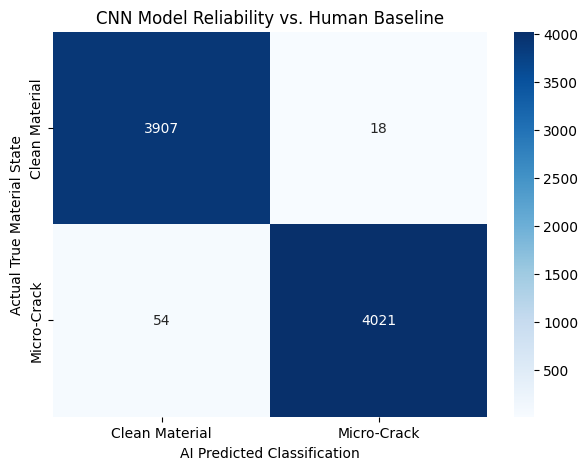

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Set model to evaluation mode
model.eval()
all_preds = []
all_labels = []

print("Generating the Confusion Matrix... plotting the results now!")

# Gather all predictions
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Create the visual matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clean Material', 'Micro-Crack'],
            yticklabels=['Clean Material', 'Micro-Crack'])
plt.title('CNN Model Reliability vs. Human Baseline')
plt.xlabel('AI Predicted Classification')
plt.ylabel('Actual True Material State')
plt.show()